In [25]:
from langgraph.graph import StateGraph, START, MessagesState, END
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain.messages import RemoveMessage

In [26]:
load_dotenv()

True

In [27]:
llm = ChatGroq(model='llama-3.3-70b-versatile')

In [28]:
def chat_node(state: MessagesState):
    message = state['messages']
    response = llm.invoke(message).content

    return {'messages': [response]}

In [29]:
def delete_old_message(state: MessagesState):

    messages = state['messages']

    if len(messages)>10:
        to_remove = messages[:6]
        return {'messages': [RemoveMessage(id=m.id) for m in to_remove]}
    
    return {}

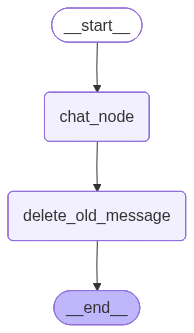

In [30]:
builder = StateGraph(MessagesState)

builder.add_node('chat_node', chat_node)
builder.add_node('delete_old_message', delete_old_message)

builder.add_edge(START, 'chat_node')
builder.add_edge('chat_node', 'delete_old_message')
builder.add_edge('delete_old_message', END)

graph = builder.compile(checkpointer=InMemorySaver())

graph

In [31]:
config = {'configurable': {'thread_id':  '1'}}
from langchain_core.messages import HumanMessage

graph.invoke(
    {"messages": [HumanMessage(content="Hi, I'm Atanu")]},
    config=config
)

graph.invoke(
    {"messages": [HumanMessage(content="Tell me about LangGraph")]},
    config=config
)

graph.invoke(
    {"messages": [HumanMessage(content="Now explain checkpointers")]},
    config=config
)

graph.invoke(
    {"messages": [HumanMessage(content="What is Langchain")]},
    config=config
)

graph.invoke(
    {"messages": [HumanMessage(content="What is Quantum Mechanics")]},
    config=config
)

graph.invoke(
    {"messages": [HumanMessage(content="What is Gen AI")]},
    config=config
)

graph.invoke(
    {"messages": [HumanMessage(content="What is my name")]},
    config=config
)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='1914cd65-1542-4058-b9c7-c54b23a79efd'),
  HumanMessage(content="LangChain is an open-source framework designed to simplify the development and deployment of large language models (LLMs) like LangGraph. It provides a set of tools and APIs that enable developers to build, train, and deploy LLMs in a more efficient and scalable way.\n\n**Key Features of LangChain:**\n\n1. **Modular Architecture**: LangChain allows developers to break down complex LLMs into smaller, modular components, making it easier to develop, test, and maintain individual components.\n2. **Chain-based Architecture**: LangChain introduces a chain-based architecture, where multiple models are connected in a sequence to process and generate text. This allows for more flexible and customizable language processing pipelines.\n3. **Pre-built Components**: LangChain provides a range of pre-built components, including token

In [32]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8
